In [12]:
#Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler, Binarizer, Normalizer
from sklearn.model_selection import train_test_split


In [13]:
import pandas as pd
df = pd.read_csv('clientes.csv')
df.head()


,ID,Nombre,Edad,Ingresos,Ciudad,Género,Gastos,Deuda,Aprobado
0,1,Ana,25,2500,Lima,F,1200,0,Sí
1,2,Juan,40,0,Cusco,M,2000,1,No
2,3,María,35,3500,Lima,F,0,0,Sí
3,4,Luis,28,3000,Arequipa,M,1500,1,Sí
4,5,Sofía,0,4000,Lima,F,1800,0,Sí


In [14]:
#Ver estructura y tipos de datos
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ID        7 non-null      int64 
 1   Nombre    7 non-null      object
 2   Edad      7 non-null      int64 
 3   Ingresos  7 non-null      int64 
 4   Ciudad    7 non-null      object
 5   Género    7 non-null      object
 6   Gastos    7 non-null      int64 
 7   Deuda     7 non-null      int64 
 8   Aprobado  7 non-null      object
dtypes: int64(5), object(4)
memory usage: 636.0+ bytes


In [15]:
#Estadísticas descriptivas
df.describe()


,ID,Edad,Ingresos,Gastos,Deuda
count,7.000000,7.000000,7.000000,7.000000,7.000000
mean,4.000000,30.142857,2614.285714,1071.428571,0.428571
std,2.160247,15.614401,1274.661486,805.634917,0.534522
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2.500000,26.500000,2500.000000,500.000000,0.000000
50%,4.000000,33.000000,2800.000000,1200.000000,0.000000
75%,5.500000,37.500000,3250.000000,1650.000000,1.000000
max,7.000000,50.000000,4000.000000,2000.000000,1.000000


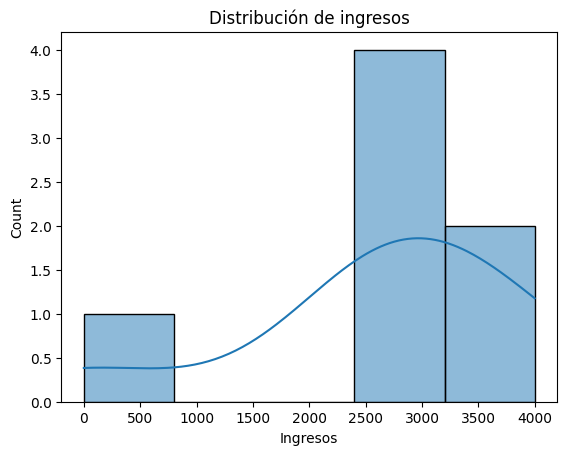

In [16]:
#Distribución de variables numéricas
sns.histplot(df['Ingresos'], bins=5, kde=True)
plt.title('Distribución de ingresos')
plt.show()


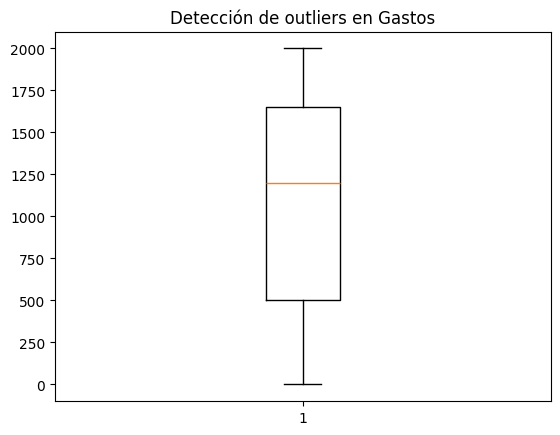

In [17]:
#Detección visual de valores atípicos (outliers)
plt.boxplot(df['Gastos'])
plt.title('Detección de outliers en Gastos')
plt.show()

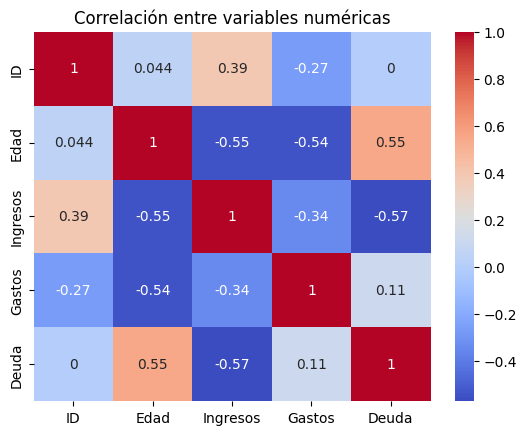

In [18]:
#Matriz de correlaciones (solo numéricas)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlación entre variables numéricas')
plt.show()


**Limpieza de Datos**

In [19]:
#Identificar valores inválidos, si hay 0, no había.
cols_invalidas = ['Edad', 'Ingresos', 'Gastos']
df[cols_invalidas] = df[cols_invalidas].replace(0, np.nan)
df.isnull().sum()


,0
ID,0
Nombre,0
Edad,1
Ingresos,1
Ciudad,0
Género,0
Gastos,2
Deuda,0
Aprobado,0


In [20]:
#Llenar los datos con la media.
df.fillna(df.mean(numeric_only=True), inplace=True)


In [21]:
#Se busca que ahora ya no haya valores en 0.
df.isnull().sum()


,0
ID,0
Nombre,0
Edad,0
Ingresos,0
Ciudad,0
Género,0
Gastos,0
Deuda,0
Aprobado,0


In [22]:
#Ahora todo tiene la media.
df

,ID,Nombre,Edad,Ingresos,Ciudad,Género,Gastos,Deuda,Aprobado
0,1,Ana,25.000000,2500.0,Lima,F,1200.0,0,Sí
1,2,Juan,40.000000,3050.0,Cusco,M,2000.0,1,No
2,3,María,35.000000,3500.0,Lima,F,1500.0,0,Sí
3,4,Luis,28.000000,3000.0,Arequipa,M,1500.0,1,Sí
4,5,Sofía,35.166667,4000.0,Lima,F,1800.0,0,Sí
5,6,Pedro,50.000000,2500.0,Cusco,M,1500.0,1,No
6,7,Rosa,33.000000,2800.0,Arequipa,F,1000.0,0,No


**Transformaciones**

In [23]:
# Copia del DataFrame
df_enc = df.copy()

# Codificar género y aprobado (binarias)
le = LabelEncoder()
df_enc['Género'] = le.fit_transform(df_enc['Género'])
df_enc['Aprobado'] = le.fit_transform(df_enc['Aprobado'])

# One-Hot Encoding para 'Ciudad'
df_enc = pd.get_dummies(df_enc, columns=['Ciudad'])


df_enc.head()

#Basicamente, Aprobado y Género se tranforman a 0 y 1 para serializar estos datos.
#Luego, se aplica dummies para clasificar la ciudad con False,true para saber.


,ID,Nombre,Edad,Ingresos,Género,Gastos,Deuda,Aprobado,Ciudad_Arequipa,Ciudad_Cusco,Ciudad_Lima
0,1,Ana,25.000000,2500.0,0,1200.0,0,1,False,False,True
1,2,Juan,40.000000,3050.0,1,2000.0,1,0,False,True,False
2,3,María,35.000000,3500.0,0,1500.0,0,1,False,False,True
3,4,Luis,28.000000,3000.0,1,1500.0,1,1,True,False,False
4,5,Sofía,35.166667,4000.0,0,1800.0,0,1,False,False,True


In [26]:
#Binarización: Lo que se hace es, por ejemplo, llevar los datos de gastos mayores a 1500 con "1"
binarizer = Binarizer(threshold=1500)
df_enc['GastosAltos'] = binarizer.fit_transform(df_enc[['Gastos']])
df_enc


,ID,Nombre,Edad,Ingresos,Género,Gastos,Deuda,Aprobado,Ciudad_Arequipa,Ciudad_Cusco,Ciudad_Lima,GastosAltos
0,1,Ana,25.000000,2500.0,0,1200.0,0,1,False,False,True,0.0
1,2,Juan,40.000000,3050.0,1,2000.0,1,0,False,True,False,1.0
2,3,María,35.000000,3500.0,0,1500.0,0,1,False,False,True,0.0
3,4,Luis,28.000000,3000.0,1,1500.0,1,1,True,False,False,0.0
4,5,Sofía,35.166667,4000.0,0,1800.0,0,1,False,False,True,1.0
5,6,Pedro,50.000000,2500.0,1,1500.0,1,0,False,True,False,0.0
6,7,Rosa,33.000000,2800.0,0,1000.0,0,0,True,False,False,0.0


In [28]:
#Escalar variables numéricas, osea se llevan las variables a otro rango.
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

cols_scale = ['Edad', 'Ingresos', 'Gastos']
df_enc[cols_scale] = scaler.fit_transform(df_enc[cols_scale])
df_enc.head()



,ID,Nombre,Edad,Ingresos,Género,Gastos,Deuda,Aprobado,Ciudad_Arequipa,Ciudad_Cusco,Ciudad_Lima,GastosAltos
0,1,Ana,0.000000,0.000000,0,0.2,0,1,False,False,True,0.0
1,2,Juan,0.600000,0.366667,1,1.0,1,0,False,True,False,1.0
2,3,María,0.400000,0.666667,0,0.5,0,1,False,False,True,0.0
3,4,Luis,0.120000,0.333333,1,0.5,1,1,True,False,False,0.0
4,5,Sofía,0.406667,1.000000,0,0.8,0,1,False,False,True,1.0


In [30]:
#División del conjunto de datos - train ( 70% - 80% ) y test 30%
X = df_enc.drop('Aprobado', axis=1)
y = df_enc['Aprobado']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)


Tamaño de entrenamiento: (4, 11)
Tamaño de prueba: (3, 11)
